In [1]:
%pylab widget
%load_ext autoreload
%autoreload 2

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# Read the mhd file from data
from gecco.utils import write_run_all_script
import os

import mpl_interactions as pli
from gecco import patient_data
import gecco as fc
import numpy as np
from gecco.utils import nrrd_to_mhd, cropping_tool

Read the nrrd_file

In [36]:
nrrd_files = {'0':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd',[1,0,2],[313,511,111,367,None,None]],
            '1':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd',[1,0,2],[313,511,111,367,None,None]],
            '2':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd',[1,0,2],[287,511,2,392,15,78]],
            '3':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd',[1,0,2],[254,None,None,None,None,None]],
            '4':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd',[2,1,0],[None,114,None,None,None,None]],
            '5':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd',[1,0,2],[None,None,None,None,None,None]],
            '6':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd',[1,0,2],[None,None,None,None,None,None]],
            '7':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd',[1,0,2],[None,None,None,None,None,None]]}


In [37]:
file_index = '4' # File index to load

Crop the nrrd file

In [42]:
cropping_tool(nrrd_file=nrrd_files[file_index][0],tr=nrrd_files[file_index][1]) # Center on center of bladder
tr = nrrd_files[file_index][1]
crop = [None,114,None,None,None,None]

interactive(children=(IntSlider(value=0, description='x_start', max=262), IntSlider(value=262, description='x_…

Write to mhd

In [43]:
nrrd_to_mhd(nrrd_files[file_index][0],force=True,tr=tr,crop=crop) # crop=[-200,None,None,None,None,None]

[2024-06-03 16:55:39,129] {utils.py:672} INFO - Directory /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2 already exists, but is being overwriten
[2024-06-03 16:55:39,130] {utils.py:677} INFO - Creating directory Pelvis_Prostate_Patient_2


[2024-06-03 16:55:39,787] {utils.py:763} INFO - Transposing the data
[2024-06-03 16:55:39,788] {utils.py:765} INFO - The spacing is [2.5   0.934 0.934]
[2024-06-03 16:55:39,789] {utils.py:767} INFO - The origin is [1469.5    -238.7905 -233.9077]
[2024-06-03 16:55:39,789] {utils.py:768} INFO - The shape is (263, 512, 512)
[2024-06-03 16:55:39,828] {utils.py:495} INFO - Loading density data from file
[2024-06-03 16:55:39,832] {utils.py:983} INFO -     Saved SchneiderMaterialsWeight1 atten to file in data/mu_over_rho/SchneiderMaterialsWeight1.csv
[2024-06-03 16:55:39,833] {utils.py:495} INFO - Loading density data from file
[2024-06-03 16:55:39,838] {utils.py:983} INFO -     Saved SchneiderMaterialsWeight2 atten to file in data/mu_over_rho/SchneiderMaterialsWeight2.csv
[2024-06-03 16:55:39,838] {utils.py:495} INFO - Loading density data from file
[2024-06-03 16:55:39,842] {utils.py:983} INFO -     Saved SchneiderMaterialsWeight3 atten to file in data/mu_over_rho/SchneiderMaterialsWeight3.

Sample the phantom

In [44]:
phantom = patient_data.patient_phantom(nrrd_files[file_index][0], 1e6, force_materials=False, is_fullfan=False) #, reload=True, sim_num = 14)

[2024-06-03 16:55:40,123] {utils.py:185} INFO - Using default geometry, DSD = 1510, nDetector = [512, 512], dDetector = [0.784, 0.784]
[2024-06-03 16:55:40,124] {utils.py:495} INFO - Loading density data from file
[2024-06-03 16:55:40,125] {utils.py:551} INFO - Loading attenuation files from /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/Pelvis_Prostate_Patient_2_materials.txt
[2024-06-03 16:55:40,125] {utils.py:552} INFO - Making attenuation files in gecco:
[2024-06-03 16:55:40,126] {utils.py:556} INFO -     Air atten file already exists, skipping...
[2024-06-03 16:55:40,126] {utils.py:556} INFO -     polyurethane atten file already exists, skipping...
[2024-06-03 16:55:40,126] {utils.py:556} INFO -     teflon atten file already exists, skipping...
[2024-06-03 16:55:40,127] {utils.py:556} INFO -     pmp atten file already exists, skipping...
[2024-06-03 16:55:40,127] {utils.py:556} INFO -     bone50 atten file already exists, skipping...
[2024-06-03 16

Plot one slice: Make sure it is axial

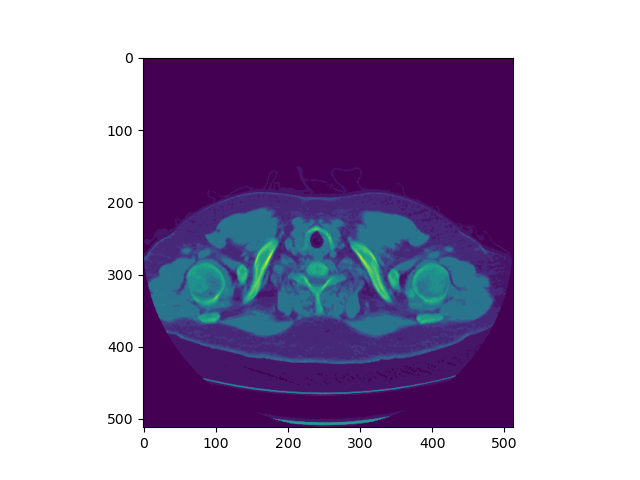

In [45]:
plt.figure()
plt.imshow(phantom.phantom[phantom.phantom.shape[0]//2,:,:])

## Write all the files

In [46]:
for nrrd in nrrd_files[:5]:

    test_file_name = nrrd[0].split('/')[-1].split('.')[0] + '_test.py'
    test_sim_dir = './test_python_scripts/'

    write_run_all_script(test_sim_dir)
    phantom.write_python_script_pelvis(os.path.join(test_sim_dir,test_file_name),tr=nrrd[1],crop=nrrd[2],nphoton=1e6,fast_mc_path='/home/jericho/Downloads/FastMC_Jan_05/FastMC_install/bin/FastMC')


TypeError: unhashable type: 'slice'

In [ ]:
file_name = nrrd_file.split('/')[-1].split('.')[0] + '.py'
sim_dir = './python_scripts/'

write_run_all_script(sim_dir)
phantom.write_python_script_pelvis(os.path.join(sim_dir,file_name),tr=tr,crop=crop,nphoton=1e10,fast_mc_path='/home/jericho/Downloads/FastMC_Jan_05/FastMC_install/bin/FastMC')